In [1]:
import ignnition
import json
from networkx.readwrite import json_graph
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import tensorflow as tf
import glob
import os
import sem
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
sns.set_style("whitegrid")
import random
import pandas as pd
import io

Utility function to parse flows

In [136]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from scipy.stats import skew

def parse_flow(file_path,file_config,nodes,links):
    def dscp_to_string(dscp_value):
        # Reverse map from DSCP decimal (after << 2) to string
        dscp_map = {
            46 : "EF",
            34 : "AF41",
            36 : "AF42",
            38 : "AF43",
            26 : "AF31",
            28 : "AF32",
            30 : "AF33",
            18 : "AF21",
            20 : "AF22",
            22 : "AF23",
            10 : "AF11",
            12 : "AF12",
            14 : "AF13",
            0: "BF"
        }
        
        return dscp_map.get(dscp_value, "UNKNOWN")
    
    
    def parse_config(config_file):
        config = {}
        config_path=config_file#"config.txt"
        with open(config_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: 
                    continue
                traffic_type, values = line.split(":")
                n_flows = values
                config[traffic_type] = {'n_flows': int(n_flows)}

        
        n_voip=config['VOIP']['n_flows']
        n_ftp=config['FTP']['n_flows']
        n_gaming=config['GAMING']['n_flows']
        n_video=config['VIDEO']['n_flows']
        return n_voip,n_ftp,n_gaming,n_video
    n_voip,n_ftp,n_gaming,n_video=parse_config(file_config)
    # Load the XML file
    
    flowmon_path=file_path#"ns-3-dev/multi-links-flow.xml"
    tree = ET.parse(flowmon_path)  # Replace with your file path
    root = tree.getroot()

    # Prepare a list to collect parsed flow data
    flow_data = []

    # Iterate over all <Flow> elements inside <FlowStats>
    #---------------nano seconds to second & bytes to Megabytes
    for flow in root.find('FlowStats').findall('Flow'):
        flow_dict = {}

        # Flow id and timestamps
        flow_dict['flow_id'] = int(flow.attrib['flowId'])
        flow_dict['time_first_tx_s'] = float(flow.attrib['timeFirstTxPacket'].replace('ns', '').replace('+', ''))*1E-9
        flow_dict['time_last_rx_s'] = float(flow.attrib['timeLastRxPacket'].replace('ns', '').replace('+', ''))*1E-9
        flow_dict['duration'] = flow_dict['time_last_rx_s'] - flow_dict['time_first_tx_s']

        # Packets/bytes stats
        tx_bytes = int(flow.attrib['txBytes'])
        rx_bytes = int(flow.attrib['rxBytes'])
        tx_packets = int(flow.attrib['txPackets'])
        rx_packets = int(flow.attrib['rxPackets'])
        lost_packets = int(flow.attrib['lostPackets'])
        times_forwarded = int(flow.attrib['timesForwarded'])
        delay_sum = float(flow.attrib['delaySum'].replace('ns', '').replace('+', ''))*1E-9
        jitter_sum = float(flow.attrib['jitterSum'].replace('ns', '').replace('+', ''))*1E-9

        # Derived metrics
        flow_dict['mean_delay'] = delay_sum / rx_packets if rx_packets>0 else 0
        flow_dict['mean_jitter'] = jitter_sum / (rx_packets-1) if rx_packets>1 else 0
        flow_dict['mean_tx_packet_size_bytes'] = tx_bytes / tx_packets if tx_packets>0 else 0
        flow_dict['mean_rx_packet_size_bytes'] = rx_bytes / rx_packets if rx_packets>0 else 0
        flow_dict['mean_tx_bit_rate'] = (tx_bytes * 8) / (flow_dict['duration'] * 1e6) if flow_dict['duration']>0 else 0
        flow_dict['mean_rx_bit_rate'] = (rx_bytes * 8) / (flow_dict['duration'] * 1e6) if flow_dict['duration']>0 else 0
        flow_dict['mean_hop_count'] = 1 + (times_forwarded / rx_packets if rx_packets>0 else 0)
        flow_dict['packet_loss_ratio'] = lost_packets / (lost_packets + rx_packets) if (lost_packets + rx_packets)>0 else 0
        flow_dict['tx_bytes'] = tx_bytes
        flow_dict['rx_bytes'] = rx_bytes
        flow_dict['tx_packets'] = tx_packets
        flow_dict['rx_packets'] = rx_packets
        flow_dict['lost_packets'] = lost_packets

        # Histogram stats
        for hist_type in ["packetSizeHistogram", "jitterHistogram", "delayHistogram"]:
            hist = flow.find(hist_type)
            if hist is not None:
                values = []
                for bin_elem in hist.findall("bin"):
                    start = float(bin_elem.get("start"))
                    width = float(bin_elem.get("width"))
                    count = int(bin_elem.get("count"))
                    value = start + width / 2
                    values.extend([value]*count)
                if values:
                    arr = np.array(values)
                    flow_dict[f"{hist_type}_mean"] = np.mean(arr)
                    flow_dict[f"{hist_type}_max"] = np.max(arr)
                    flow_dict[f"{hist_type}_min"] = np.min(arr)
                    flow_dict[f"{hist_type}_std"] = np.std(arr)
                    flow_dict[f"{hist_type}_median"] = np.median(arr)
                    flow_dict[f"{hist_type}_skew"] = skew(arr)
                else:
                    flow_dict[f"{hist_type}_mean"] = 0
                    flow_dict[f"{hist_type}_max"] = 0
                    flow_dict[f"{hist_type}_min"] = 0
                    flow_dict[f"{hist_type}_std"] = 0
                    flow_dict[f"{hist_type}_median"] = 0
                    flow_dict[f"{hist_type}_skew"] = 0
            else:
                flow_dict[f"{hist_type}_mean"] = 0
                flow_dict[f"{hist_type}_max"] = 0
                flow_dict[f"{hist_type}_min"] = 0
                flow_dict[f"{hist_type}_std"] = 0
                flow_dict[f"{hist_type}_median"] = 0
                flow_dict[f"{hist_type}_skew"] = 0

        flow_data.append(flow_dict)

    classifier_info = {}
    for flow in root.find('Ipv4FlowClassifier').findall('Flow'):
        flow_id = int(flow.attrib['flowId'])

        # Find the <Dscp> child tag inside this flow
        dscp_elem = flow.find('Dscp')
        if dscp_elem is not None:
            # Convert hex string like "0x4" to int
            dscp_hex = dscp_elem.attrib.get('value')
            dscp_val = int(dscp_hex, 16)
            dscp_packets = dscp_elem.attrib.get('packets')
            tos_hex = hex(dscp_val << 2)
            

            
        else:
            dscp_value = None
            tos_val=None
            dscp_packets = None

        classifier_info[flow_id] = {
            #review for routing
            'src_ip': flow.attrib['sourceAddress'],
            'dst_ip': flow.attrib['destinationAddress'],
            'src_port': int(flow.attrib.get('sourcePort', 0)),
            'dst_port': int(flow.attrib.get('destinationPort', 0)),
            'protocol': flow.attrib['protocol'],
            'DSCP': dscp_hex,
            'tos': tos_hex,
            'DSCP_packets': dscp_packets

        }

    # Merge with previous stats if needed
    for row in flow_data:
        fid = row['flow_id']
        if fid in classifier_info:
            row.update(classifier_info[fid])
    df_flowmon = pd.DataFrame(flow_data)
    # Base ports
    base_ports = {
        'VOIP': 5060,
        'FTP': 21,
        'GAMING': 5000,
        'VIDEO': 16384
    }
    # Generate sets of ports per traffic type
    voip_ports = set(base_ports['VOIP'] + i for i in range(n_voip))
    ftp_ports = set(base_ports['FTP'] + i for i in range(n_ftp))
    gaming_ports = set(base_ports['GAMING'] + i for i in range(n_gaming))
    video_ports = set(base_ports['VIDEO'] + i for i in range(n_video))

    # Define conditions
    conditions = [
        df_flowmon['src_port'].isin(voip_ports) | df_flowmon['dst_port'].isin(voip_ports),
        df_flowmon['src_port'].isin(ftp_ports) | df_flowmon['dst_port'].isin(ftp_ports),
        df_flowmon['src_port'].isin(gaming_ports) | df_flowmon['dst_port'].isin(gaming_ports),
        df_flowmon['src_port'].isin(video_ports) | df_flowmon['dst_port'].isin(video_ports),
    ]

    choices = ['VOIP', 'FTP', 'GAMING', 'VIDEO']

    # Apply mapping
    df_flowmon['traffic_type'] = np.select(conditions, choices, default='OTHER')
    def hex_to_int(x):
        x = str(x)
        return int(x, 16) if x.startswith("0x") else int(x)
    df_flowmon['dscp_tag'] = df_flowmon['DSCP'].apply(hex_to_int).apply(dscp_to_string)



    df_flowmon['flow_6tuple'] = (df_flowmon['src_ip'].astype(str) + '-' +
                            df_flowmon['dst_ip'].astype(str) + '-' +
                            df_flowmon['src_port'].astype(str) + '-' + 
                            df_flowmon['dst_port'].astype(str) + '-' +
                            df_flowmon['protocol'].astype(str)+'-'+
                            df_flowmon['dscp_tag'].astype(str))
    
    ip_to_node = {
    ip: row["ID"]
    for _, row in nodes.iterrows()
    for ip in row["IP_Addresses"].split()
    }
    def assign_link(ip):
        try:
            # Split the IP by '.' and take the third octet (index 2)
            third_octet = int(ip.split('.')[2])
            return third_octet
        except (IndexError, ValueError):
            return None
    def assign_interface(ip):
        try:
            # Split the IP by '.' and take the forth octet (index 3)
            forth_octet = int(ip.split('.')[3])
            return forth_octet
        except (IndexError, ValueError):
            return None
          
  
    df_flowmon["src_node"] = df_flowmon["src_ip"].map(ip_to_node)
    df_flowmon["dst_node"] = df_flowmon["dst_ip"].map(ip_to_node)
    #assign link
    df_flowmon['link'] = df_flowmon['dst_ip'].apply(assign_link)
    df_flowmon['interface_number'] = df_flowmon['src_ip'].apply(assign_interface) #to identify if it is up or down link
    # Merge flows with links on IP
    df_flowmon = df_flowmon.merge(
        links[['SrcIP', 'QueueDiscType','Child_name','Child_size']],
        left_on='src_ip',
        right_on='SrcIP',
        how='left'   # keep all flows even if some IPs are missing in links
    )

    # Optional: drop the duplicate SrcIP column
    df_flowmon.drop(columns=['SrcIP'], inplace=True)
    return df_flowmon

Utility function to have link summaries

In [108]:
#do all the preprocessing of the flowmonitor files

def link_summary_flows(flows,nodes):

    # Compute total throughput per link
    total_per_link = flows.groupby('link')['mean_tx_bit_rate'].transform('sum')
    # Compute percentage bandwidth per flow on its link
    flows['bandwidth_pct_%'] = flows['mean_tx_bit_rate'] / total_per_link * 100

    link_summary = flows.groupby('link').agg(
    mean_throughput_bps=('mean_tx_bit_rate', 'mean'),
    mean_delay_s=('delayHistogram_mean', 'mean'),
    mean_jitter_s=('jitterHistogram_mean', 'mean'),
    mean_lost_packets=('lost_packets', 'mean'),
    flows=('flow_id', set),
    dscp_tag=('dscp_tag',set)
    ).reset_index()
    

    return flows, link_summary


Retrieve experiments dataframes: nodes, links, flows and link summary

In [137]:
from pathlib import Path
from tqdm import tqdm

base_dir = Path("testResults/data")
experiment_info={}
# Iterate over each experiment folder
#for experiment_dir in base_dir.iterdir():
for experiment_dir in tqdm(base_dir.iterdir(), desc="Processing experiments"):
    if experiment_dir.is_dir():  # make sure it's a directory
        flow_file = experiment_dir / "multi-links-flow.xml"
        links_file = experiment_dir / "links.txt"
        nodes_file = experiment_dir / "nodes.txt"
        config_file= experiment_dir / "config.txt"
        experiment_name = str(experiment_dir).split("/")[-1]
        experiment_info[experiment_name] = {}

        if flow_file.exists() and links_file.exists() and nodes_file.exists() and config_file.exists():
            #print(f"\nProcessing {experiment_dir.name}")  #debug
            #print("-", end="", flush=True)
            nodes = pd.read_csv(nodes_file, sep='\t')    #ID	QueueDiscType	QueueDiscSizePackets
            links = pd.read_csv(links_file, sep='\t')
            #print(nodes)
            #print(links)
            flows_df=parse_flow(flow_file,config_file,nodes,links)
            #print(flows_df.head(2))
            flows_df,link_summary=link_summary_flows(flows_df,nodes)
           
            experiment_info[experiment_name]['nodes']=nodes
            experiment_info[experiment_name]['links']=links
            experiment_info[experiment_name]['flows']=flows_df
            experiment_info[experiment_name]['link_summary']=link_summary

print("\nDone!")


Processing experiments: 120it [00:04, 28.27it/s]


Done!


### Data analysis

#### For 1 experiment

In [138]:
experiment_info.keys()

dict_keys(['264b7705-43ad-4bc0-9ded-983fffb64d6e', 'c04037ce-82eb-49a8-a6f6-7ff087c724c7', 'e8f1d5e8-765a-4f69-a4fb-9dbe3add77a1', 'f4916df7-929e-42e0-a8fd-fbdf736b9266', '689d6d73-e5dc-4b0d-aa16-1bf44ee48367', '52ff8bb5-c255-4d1b-87b6-c6fb794b5d9f', 'da4b64eb-52eb-4519-912b-e7a6ca6c80bf', 'aa43c032-4ed6-4433-90b0-a28e417d341f', 'cdb75337-fa70-4e15-9f84-c322b837994b', '3d040fc8-9cdd-43fb-aa0b-af842b49ace8', '7377e396-de53-472a-ad6e-6c050fd4b557', 'fb1dd1c2-923b-4b56-93a2-243f1baa5ef5', '616574b2-8313-4e7b-8c41-cfdc46a9bb2e', 'a609efb0-460d-4985-a998-79a9a3bce9e2', '3918555c-81b9-4532-8202-18eabd25ca11', '7eda8a76-e126-42e2-9ada-48d12fe4540e', 'f3b10a20-0a2f-4859-808c-bcbbf12003ad', 'abbfaa2e-8893-4362-b114-3d81fa61c25c', 'a71dde17-b0c4-41ae-bf8c-94ca25505ed9', 'ffad0842-cdb2-4007-b687-352f7371c249', '0a487bfc-c488-462e-92e7-311c3ece51eb', 'd2e27349-ef18-451e-b160-ff7b9f67eb5e', '3800b2c3-096c-4706-b226-de694ad5d2a9', '3bc140b9-b8ae-4e98-a265-0e6566cd9d65', 'dcc15fe9-75d6-46ba-af97-0931

Link summary

In [139]:
experiment_info['264b7705-43ad-4bc0-9ded-983fffb64d6e']['link_summary']

,link,mean_throughput_bps,mean_delay_s,mean_jitter_s,mean_lost_packets,flows,dscp_tag
0,1,0.041202,0.006805,0.000877,0.0,"{8, 2, 5, 7}","{AF31, AF41}"
1,2,0.268453,0.092241,0.004611,14.5,"{3, 6}",{BF}
2,3,0.009868,0.005995,0.000500,0.0,"{1, 4}",{EF}


In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: flows_df has columns 'dscp' and 'delay'
flows_df = experiment_info['264b7705-43ad-4bc0-9ded-983fffb64d6e']['flows']
KPI='mean_delay' #lost_packets, mean_delay, mean_jitter, mean_rx_bit_rate
# Compute mean delay per DSCP
mean_delay_per_dscp = flows_df.groupby('dscp_tag')[KPI].mean().reset_index() 

# # Plot
# plt.figure(figsize=(5,3))
# sns.barplot(x='dscp_tag', y=KPI, data=mean_delay_per_dscp, palette="viridis")
# plt.xlabel('DSCP Tag')
# plt.ylabel(f'{KPI}')
# plt.title(f'{KPI} per DSCP - Experiment {experiment_name}')

# plt.show()


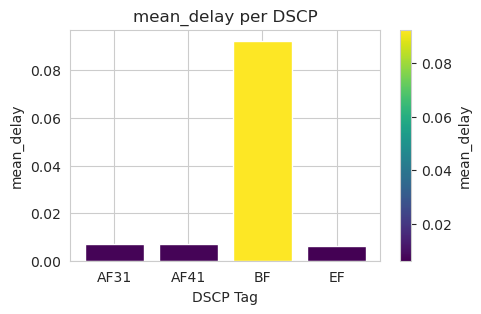

In [141]:
# Normalize mean_delay to [0,1] for colormap
import matplotlib.cm as cm
norm = plt.Normalize(mean_delay_per_dscp[KPI].min(), mean_delay_per_dscp[KPI].max())
colors = cm.viridis(norm(mean_delay_per_dscp[KPI]))

# Plot
plt.figure(figsize=(5,3))
bars = plt.bar(mean_delay_per_dscp['dscp_tag'], mean_delay_per_dscp[KPI], color=colors)
plt.xlabel('DSCP Tag')
plt.ylabel(f'{KPI}')
plt.title(f'{KPI} per DSCP')

# Optional: add colorbar to show mapping
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label(f'{KPI}')

plt.show()

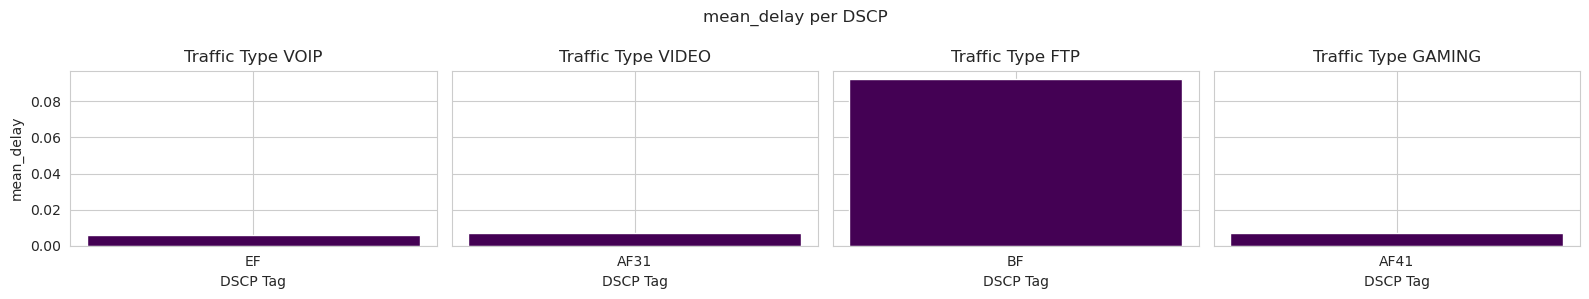

In [142]:
traffic_types = flows_df['traffic_type'].unique()
n_types = len(traffic_types)

fig, axes = plt.subplots(1, n_types, figsize=(4*n_types, 3), sharey=True)

for ax, t_type in zip(axes, traffic_types):
    subset = flows_df[flows_df['traffic_type'] == t_type]
    
    # Compute mean delay per DSCP tag
    mean_delay = subset.groupby('dscp_tag')[KPI].mean().reset_index()
    
    # Color by delay intensity
    norm = plt.Normalize(mean_delay[KPI].min(), mean_delay[KPI].max())
    colors = cm.viridis(norm(mean_delay[KPI]))
    
    ax.bar(mean_delay['dscp_tag'], mean_delay[KPI], color=colors)
    ax.set_title(f"Traffic Type {t_type}")
    ax.set_xlabel("DSCP Tag")
    if ax == axes[0]:
        ax.set_ylabel(f"{KPI}")

# Add colorbar
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
#fig.colorbar(sm, ax=axes, orientation='vertical', label='Mean Delay (ms)')
plt.suptitle(f'{KPI} per DSCP')
plt.tight_layout()
plt.show()

#### mean over all experiments

In [143]:
import pandas as pd

# List to store all flows
all_flows = []

for exp_name, info in experiment_info.items():
    #print(info.keys())
    if 'flows' in info:
        df = info['flows'].copy()
        df['experiment'] = exp_name
        all_flows.append(df)
    else:
        print(f"Warning: No flows found for experiment {exp_name}")

# Combine all experiments into one DataFrame
combined_flows = pd.concat(all_flows, ignore_index=True)


In [ ]:
#combined_flows.columns

In [144]:
# Mean delay per experiment, traffic type, and dscp_tag
mean_per_exp = combined_flows.groupby(['experiment', 'traffic_type', 'dscp_tag','QueueDiscType','Child_name','Child_size'])[KPI].mean().reset_index()


In [146]:
# Average across experiments
mean_over_experiments = mean_per_exp.groupby(['traffic_type', 'dscp_tag','QueueDiscType','Child_name','Child_size'])[KPI].mean().reset_index()

mean_over_experiments.head(5)


,traffic_type,dscp_tag,QueueDiscType,Child_name,Child_size,mean_delay
0,FTP,BF,ns3::PrioQueueDisc,ns3::CoDelQueueDisc,10p,0.067124
1,FTP,BF,ns3::PrioQueueDisc,ns3::FifoQueueDisc,10p,0.092443
2,FTP,BF,ns3::PrioQueueDisc,ns3::PfifoFastQueueDisc,10p,0.092438
3,FTP,BF,ns3::PrioQueueDisc,ns3::PieQueueDisc,10p,0.069378
4,FTP,BF,ns3::PrioQueueDisc,ns3::RedQueueDisc,10p,0.091033


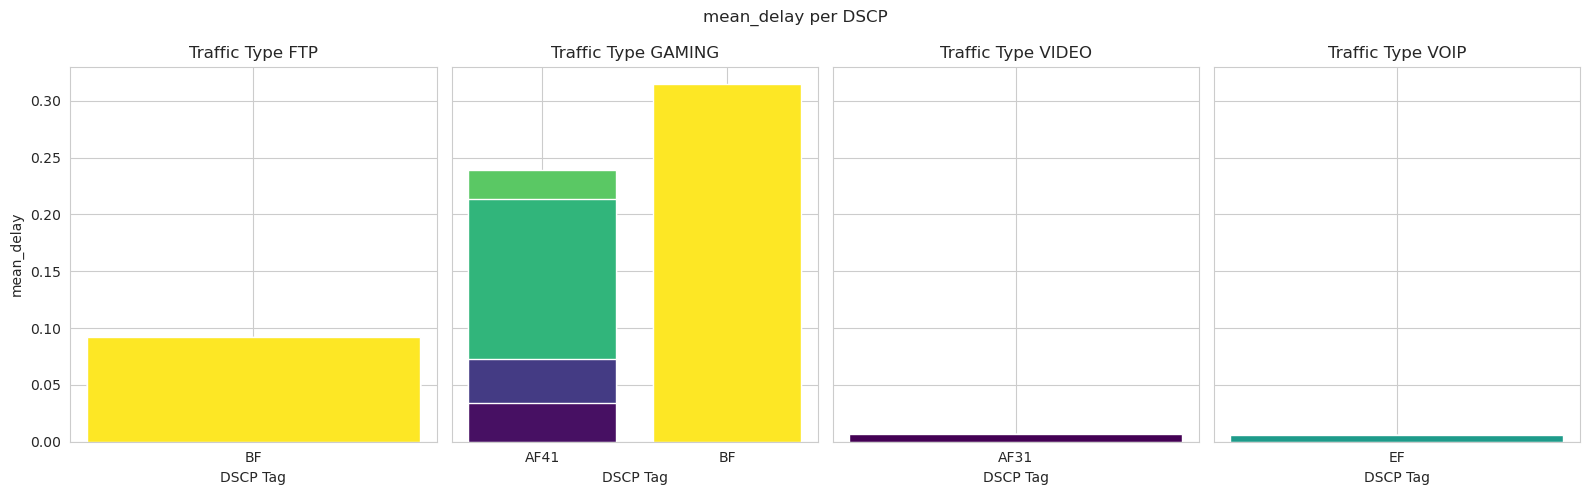

In [147]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

traffic_types = mean_over_experiments['traffic_type'].unique()
n_types = len(traffic_types)

fig, axes = plt.subplots(1, n_types, figsize=(4*n_types, 5), sharey=True)

for ax, t_type in zip(axes, traffic_types):
    subset = mean_over_experiments[mean_over_experiments['traffic_type'] == t_type]
    
    norm = plt.Normalize(subset[KPI].min(), subset[KPI].max())
    colors = cm.viridis(norm(subset[KPI]))
    
    ax.bar(subset['dscp_tag'], subset[KPI], color=colors)
    ax.set_title(f"Traffic Type {t_type}")
    ax.set_xlabel("DSCP Tag")
    if ax == axes[0]:
        ax.set_ylabel(f"{KPI}")

sm = cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(mean_over_experiments[KPI].min(),
                                                           mean_over_experiments[KPI].max()))
sm.set_array([])
#fig.colorbar(sm, ax=axes, orientation='vertical', label='Mean Delay (ms)')
plt.suptitle(f'{KPI} per DSCP')
plt.tight_layout()
plt.show()


TypeError: zip argument #1 must support iteration

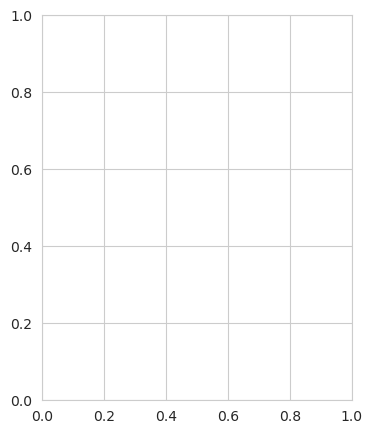

In [148]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Unique queue types
queue_types = mean_over_experiments['QueueDiscType'].unique()
n_types = len(queue_types)

fig, axes = plt.subplots(1, n_types, figsize=(4*n_types, 5), sharey=True)

for ax, q_type in zip(axes, queue_types):
    subset = mean_over_experiments[mean_over_experiments['QueueDiscType'] == q_type]
    
    # Normalize colors based on mean_delay in this subset
    norm = plt.Normalize(subset[KPI].min(), subset[KPI].max())
    colors = cm.viridis(norm(subset[KPI]))
    
    ax.bar(subset['dscp_tag'], subset[KPI], color=colors)
    ax.set_title(f"Queue: {q_type}")
    ax.set_xlabel("DSCP Tag")
    if ax == axes[0]:
        ax.set_ylabel(f"{KPI}")

# Optional: shared colorbar for all subplots
sm = cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(mean_over_experiments[KPI].min(),
                                                           mean_over_experiments[KPI].max()))
sm.set_array([])
#fig.colorbar(sm, ax=axes, orientation='vertical', label='Mean Delay (ms)')

plt.tight_layout()
plt.show()


Per queue types

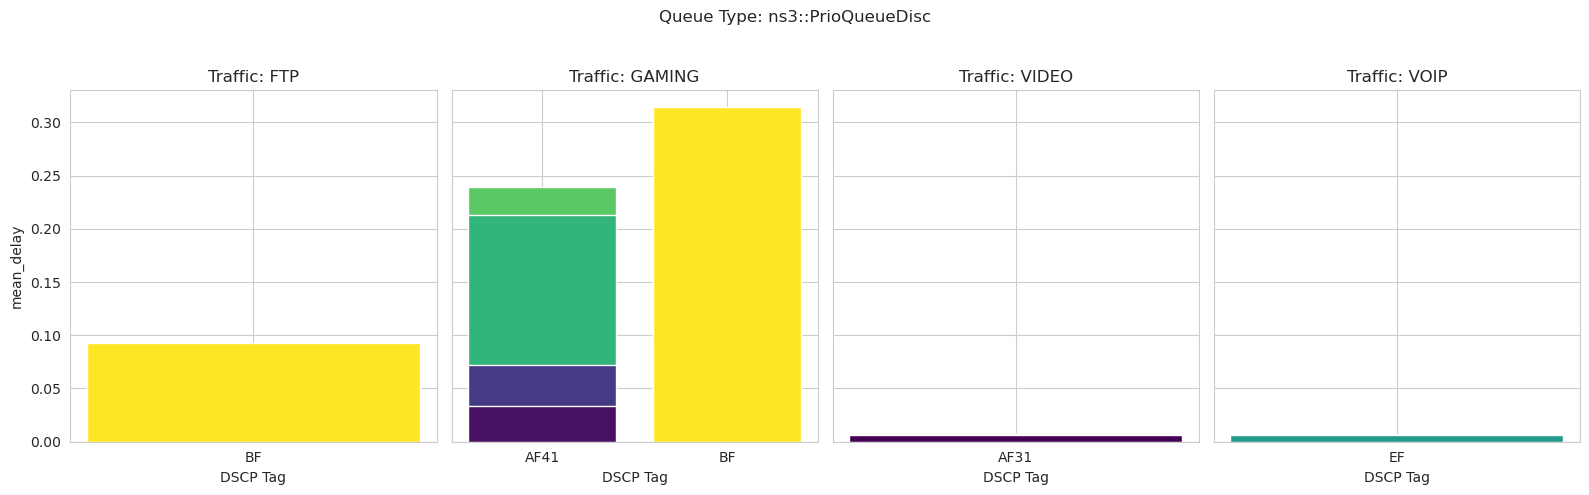

In [149]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

queue_types = mean_over_experiments['QueueDiscType'].unique()
traffic_types = mean_over_experiments['traffic_type'].unique()
n_traffic = len(traffic_types)

for q_type in queue_types:
    subset_queue = mean_over_experiments[mean_over_experiments['QueueDiscType'] == q_type]
    
    fig, axes = plt.subplots(1, n_traffic, figsize=(4*n_traffic, 5), sharey=True)
    
    for ax, t_type in zip(axes, traffic_types):
        subset = subset_queue[subset_queue['traffic_type'] == t_type]
        
        if not subset.empty:
            # Normalize colors for this subset
            norm = plt.Normalize(subset[KPI].min(), subset[KPI].max())
            colors = cm.viridis(norm(subset[KPI]))
            
            ax.bar(subset['dscp_tag'], subset[KPI], color=colors)
            ax.set_title(f"Traffic: {t_type}")
            ax.set_xlabel("DSCP Tag")
            if ax == axes[0]:
                ax.set_ylabel(f"{KPI}")
    
    # Shared colorbar for all traffic types in this queue
    sm = cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(subset_queue[KPI].min(),
                                                               subset_queue[KPI].max()))
    sm.set_array([])
    #fig.colorbar(sm, ax=axes, orientation='vertical', label='Mean Delay (ms)')
    
    fig.suptitle(f"Queue Type: {q_type}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


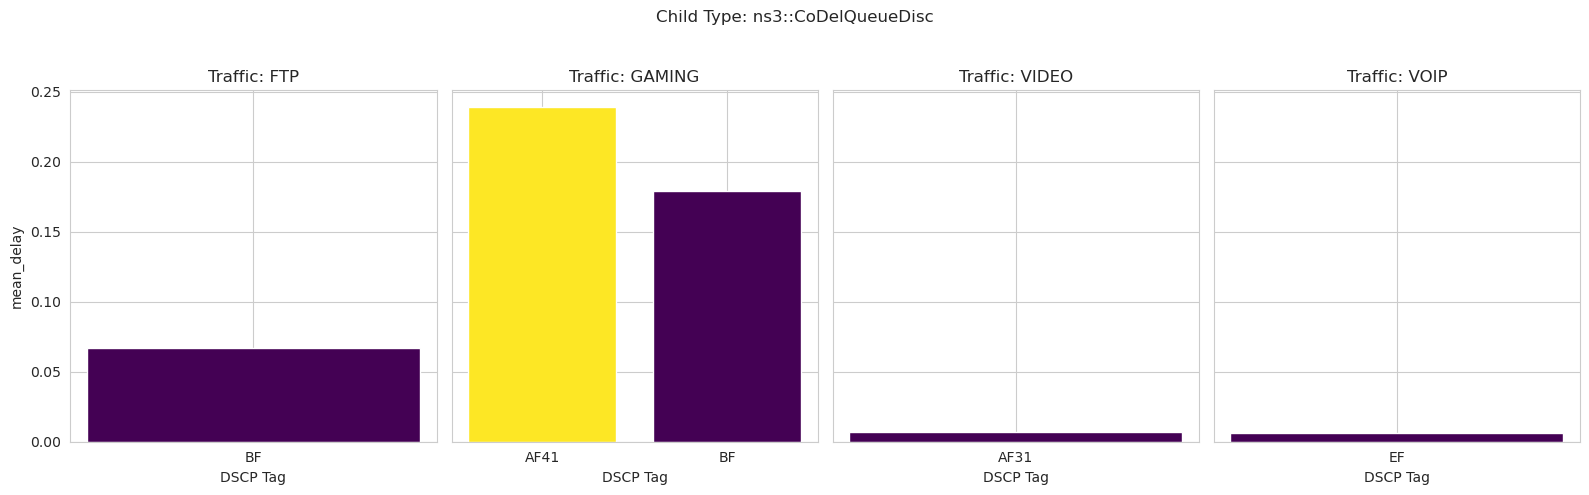

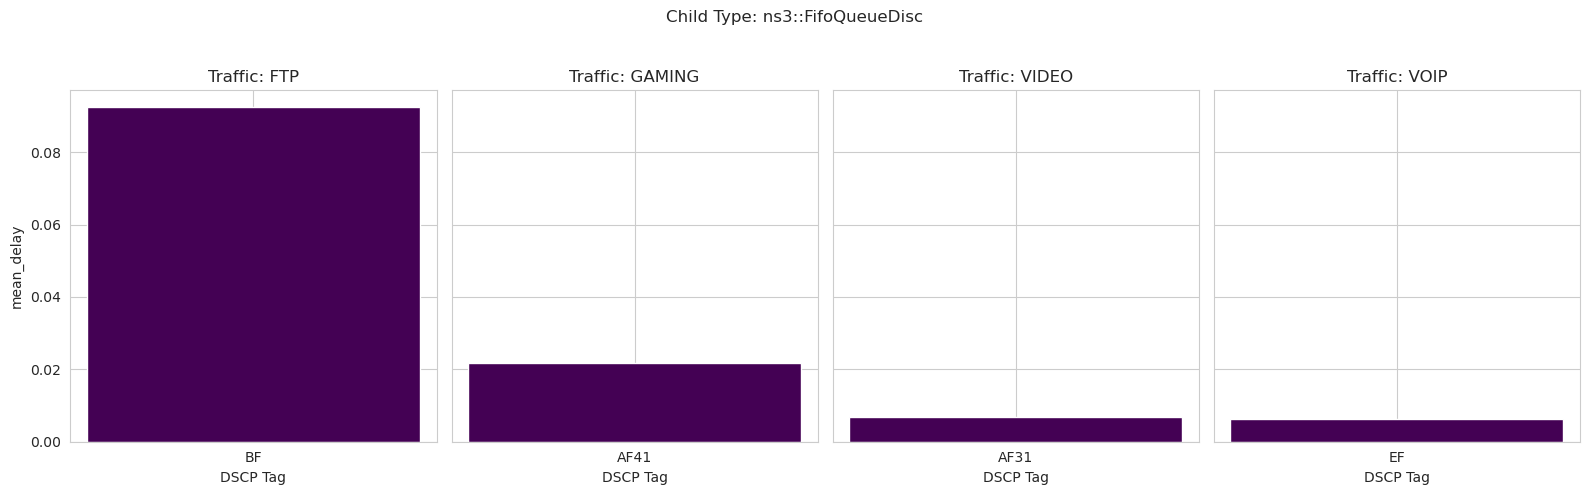

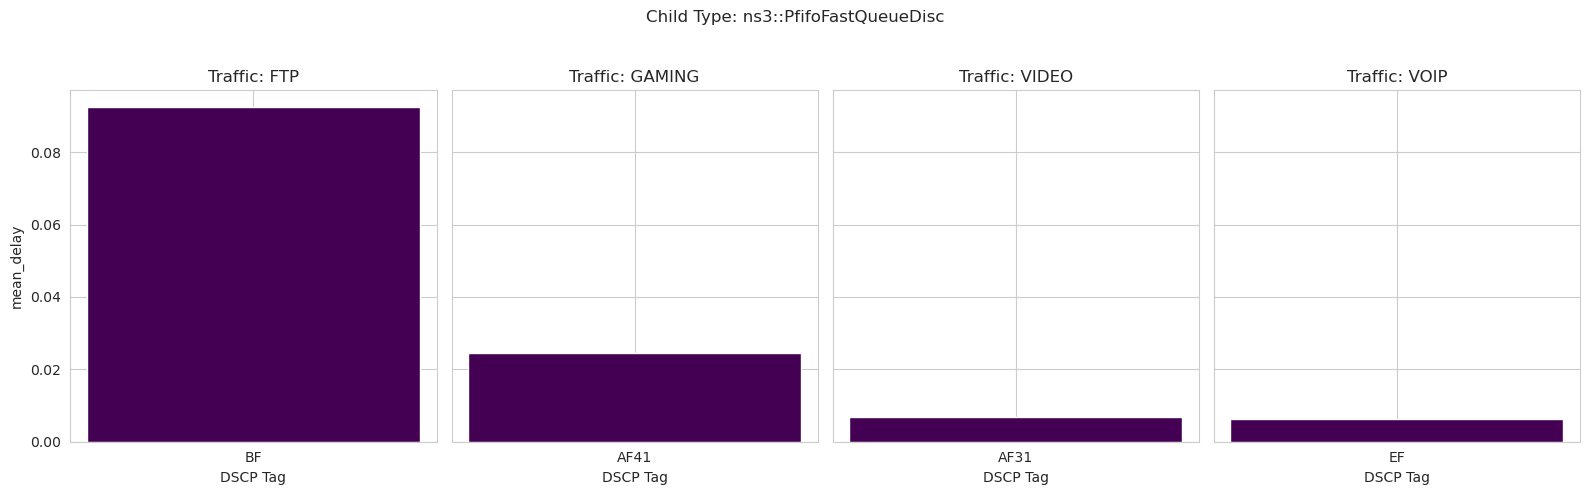

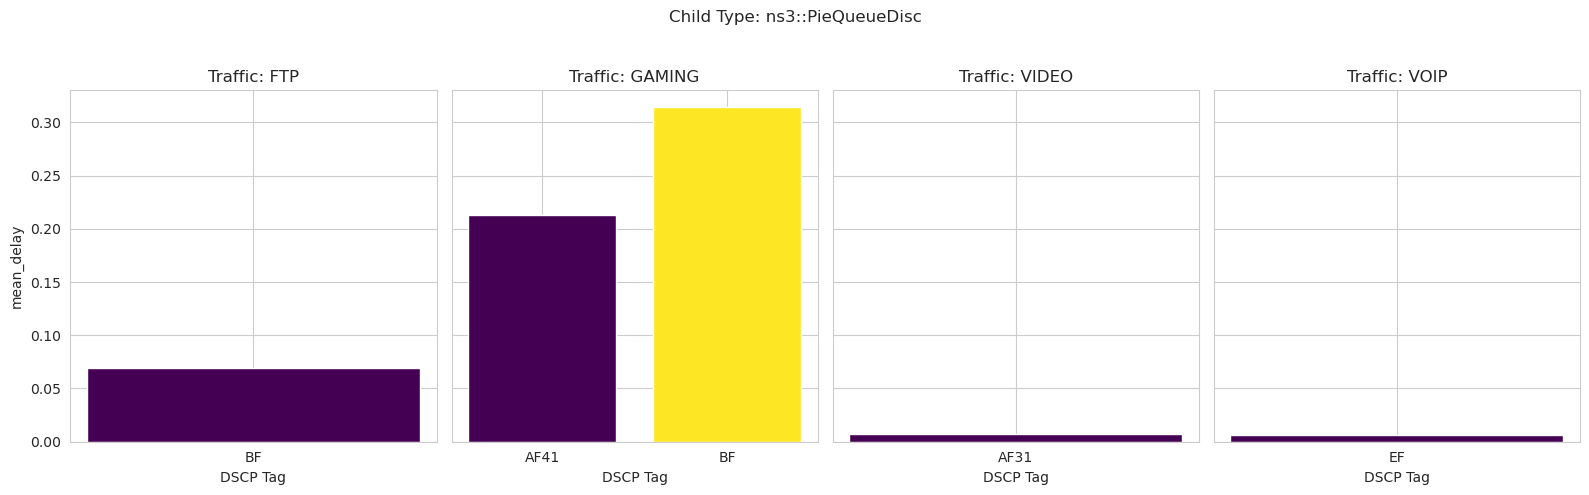

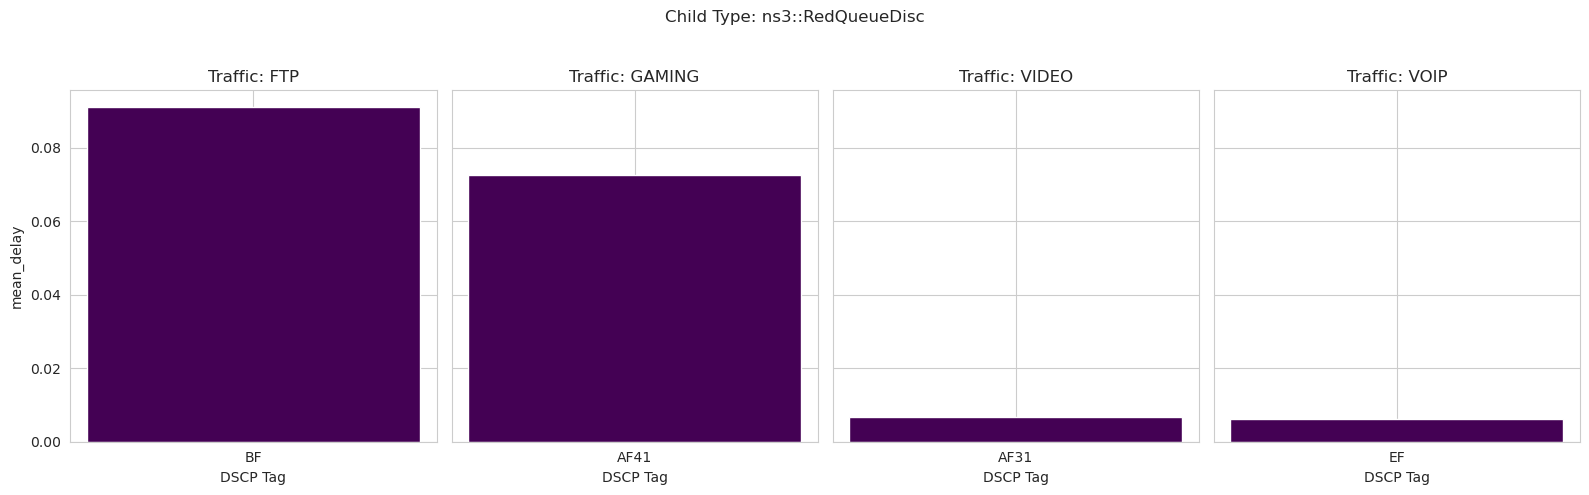

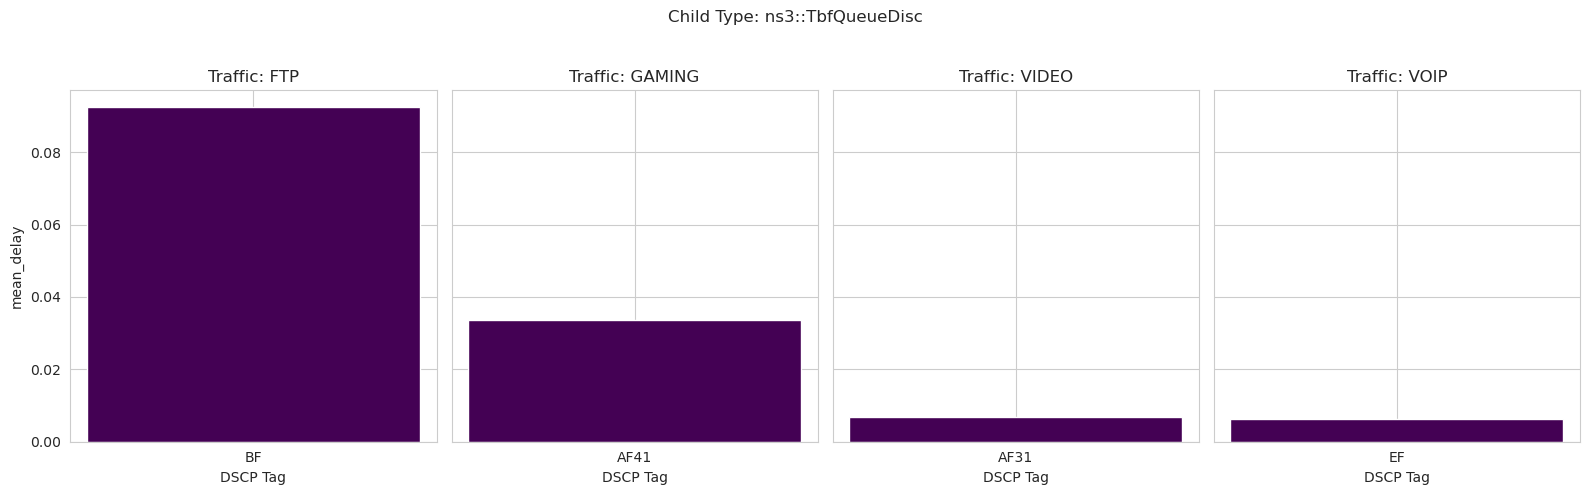

In [154]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

queue_types = mean_over_experiments['Child_name'].unique()
traffic_types = mean_over_experiments['traffic_type'].unique()
n_traffic = len(traffic_types)

for q_type in queue_types:
    subset_queue = mean_over_experiments[mean_over_experiments['Child_name'] == q_type]
    
    fig, axes = plt.subplots(1, n_traffic, figsize=(4*n_traffic, 5), sharey=True)
    
    for ax, t_type in zip(axes, traffic_types):
        subset = subset_queue[subset_queue['traffic_type'] == t_type]
        
        if not subset.empty:
            # Normalize colors for this subset
            norm = plt.Normalize(subset[KPI].min(), subset[KPI].max())
            colors = cm.viridis(norm(subset[KPI]))
            
            ax.bar(subset['dscp_tag'], subset[KPI], color=colors)
            ax.set_title(f"Traffic: {t_type}")
            ax.set_xlabel("DSCP Tag")
            if ax == axes[0]:
                ax.set_ylabel(f"{KPI}")
    
    # Shared colorbar for all traffic types in this queue
    sm = cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(subset_queue[KPI].min(),
                                                               subset_queue[KPI].max()))
    sm.set_array([])
    #fig.colorbar(sm, ax=axes, orientation='vertical', label='Mean Delay (ms)')
    
    fig.suptitle(f"Child Type: {q_type}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


**Investigate link forwarding for the whole dataset**

In [68]:
link_summary.columns

Index(['link', 'mean_throughput_bps', 'mean_delay_s', 'mean_jitter_s', 'flows',
       'dscp_tag'],
      dtype='object')

In [150]:
import pandas as pd

# Collect all link_summary DataFrames
dfs = [exp["link_summary"] for exp in experiment_info.values() if "link_summary" in exp]

if dfs:
    all_links = pd.concat(dfs, ignore_index=True)

    # Drop 'flows' column
    all_links = all_links.drop(columns=["flows"])

    # Numeric columns to average
    numeric_cols = ["mean_throughput_bps", "mean_delay_s", "mean_jitter_s","mean_lost_packets"]

    # Compute mean of numeric metrics per link
    mean_links = all_links.groupby("link")[numeric_cols].mean().reset_index()

    # Function to compute dominant and least DSCP with counts
    def dscp_agg(series):
        # Flatten sets/lists into individual DSCPs
        flat = []
        for item in series:
            if isinstance(item, (set, list)):
                flat.extend(item)
            else:
                flat.append(item)
        
        counts = pd.Series(flat).value_counts()
        dominant = counts.idxmax()
        least = counts.idxmin()
        return dominant,counts.max(),least,counts.min()
        '''
        return pd.Series({
            "dominant_dscp": dominant,
            "dominant_count": counts.max(),
            "least_dscp": least,
            "least_count": counts.min()
        })
        '''


    # Apply aggregation on dscp_tag
    dscp_info = all_links.groupby("link")["dscp_tag"].apply(dscp_agg).reset_index()

    # Merge numeric means with DSCP info
    mean_links = mean_links.merge(dscp_info, on="link")

mean_links


,link,mean_throughput_bps,mean_delay_s,mean_jitter_s,mean_lost_packets,dscp_tag
0,1,0.096835,0.025321,0.005717,2.766667,"(AF31, 100, BF, 20)"
1,2,0.237476,0.085492,0.015921,13.654167,"(BF, 100, EF, 20)"
2,3,0.009047,0.005994,0.000500,0.000000,"(EF, 100, EF, 100)"


In [151]:
# Extract dominant and least DSCP columns
mean_links["dominant_dscp"] = mean_links["dscp_tag"].apply(lambda x: x[0])
mean_links["dominant_count"] = mean_links["dscp_tag"].apply(lambda x: x[1])
mean_links["least_dscp"] = mean_links["dscp_tag"].apply(lambda x: x[2])
mean_links["least_count"] = mean_links["dscp_tag"].apply(lambda x: x[3])
'''
# Plot mean_delay per link, colored by dominant DSCP
plt.figure(figsize=(6,4))
sns.barplot(x="link", y="mean_delay_s", hue="dominant_dscp", data=mean_links, dodge=False)
plt.xlabel("Link")
plt.ylabel("Mean Delay (s)")
plt.title("Mean Delay per Link (colored by dominant DSCP)")
plt.show()
'''

'\n# Plot mean_delay per link, colored by dominant DSCP\nplt.figure(figsize=(6,4))\nsns.barplot(x="link", y="mean_delay_s", hue="dominant_dscp", data=mean_links, dodge=False)\nplt.xlabel("Link")\nplt.ylabel("Mean Delay (s)")\nplt.title("Mean Delay per Link (colored by dominant DSCP)")\nplt.show()\n'

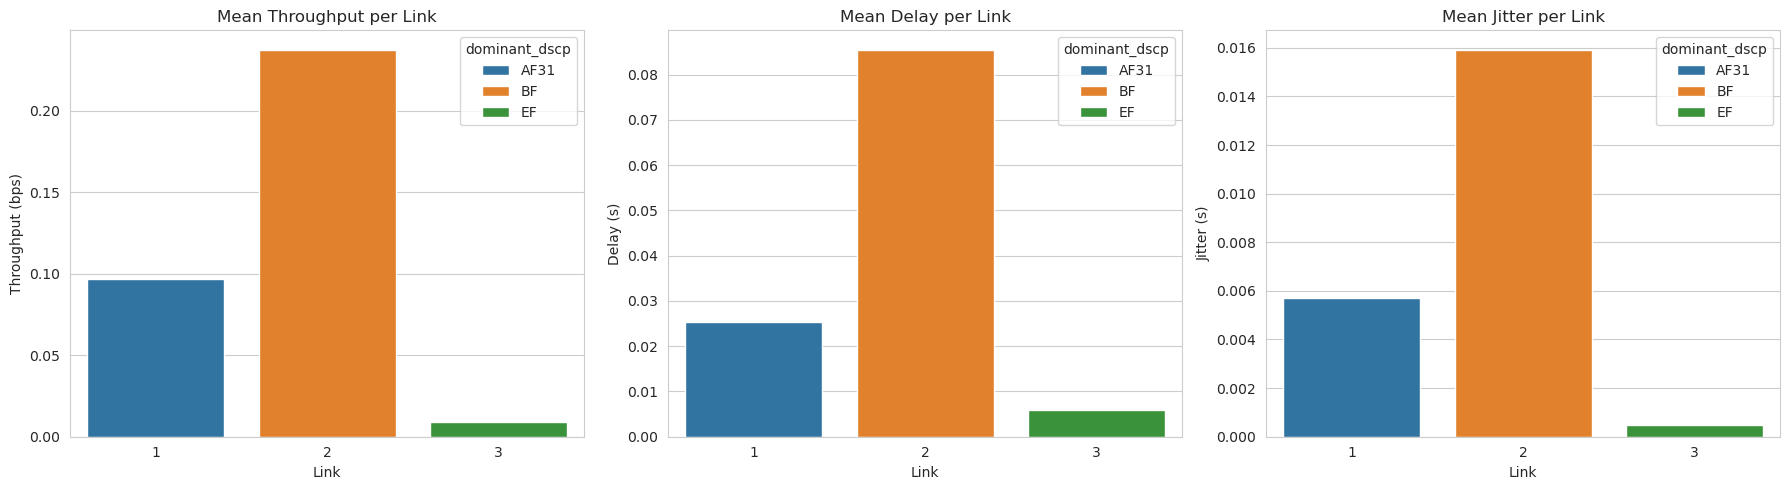

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: assume mean_links is your DataFrame and dominant/least DSCP columns exist
# Create a color palette for all unique DSCPs
all_dscps = pd.concat([mean_links['dominant_dscp'], mean_links['least_dscp']]).unique()
palette = dict(zip(all_dscps, sns.color_palette("tab10", n_colors=len(all_dscps))))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Throughput bar plot
sns.barplot(
    x="link", y="mean_throughput_bps", hue="dominant_dscp",
    dodge=False, ax=axes[0], data=mean_links, palette=palette
)
axes[0].set_title("Mean Throughput per Link")
axes[0].set_xlabel("Link")
axes[0].set_ylabel("Throughput (bps)")

# Delay bar plot
sns.barplot(
    x="link", y="mean_delay_s", hue="dominant_dscp",
    dodge=False, ax=axes[1], data=mean_links, palette=palette
)
axes[1].set_title("Mean Delay per Link")
axes[1].set_xlabel("Link")
axes[1].set_ylabel("Delay (s)")

# Jitter bar plot
sns.barplot(
    x="link", y="mean_jitter_s", hue="dominant_dscp",
    dodge=False, ax=axes[2], data=mean_links, palette=palette
)
axes[2].set_title("Mean Jitter per Link")
axes[2].set_xlabel("Link")
axes[2].set_ylabel("Jitter (s)")

# Adjust layout and show
plt.tight_layout()
plt.show()


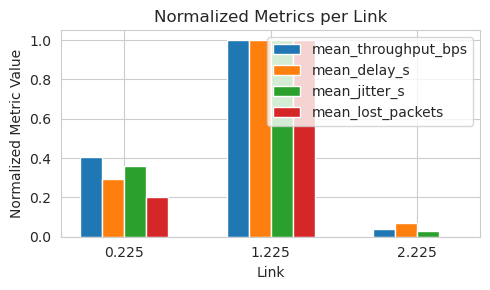

In [153]:
metrics = ["mean_throughput_bps", "mean_delay_s", "mean_jitter_s", "mean_lost_packets"]
n_links = len(mean_links)
width = 0.15  # width of each bar

# Normalize metrics for plotting
df_norm = mean_links.copy()
for m in metrics:
    df_norm[m] = mean_links[m] / mean_links[m].max()

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(n_links)

for i, metric in enumerate(metrics):
    ax.bar(
        x + i*width, df_norm[metric], width,
        label=metric
    )
    

# Labels
ax.set_xticks(x + width*1.5)

ax.set_xlabel("Link")
ax.set_ylabel("Normalized Metric Value")
ax.set_title("Normalized Metrics per Link")
ax.legend()

plt.tight_layout()
plt.show()